<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/BOA002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

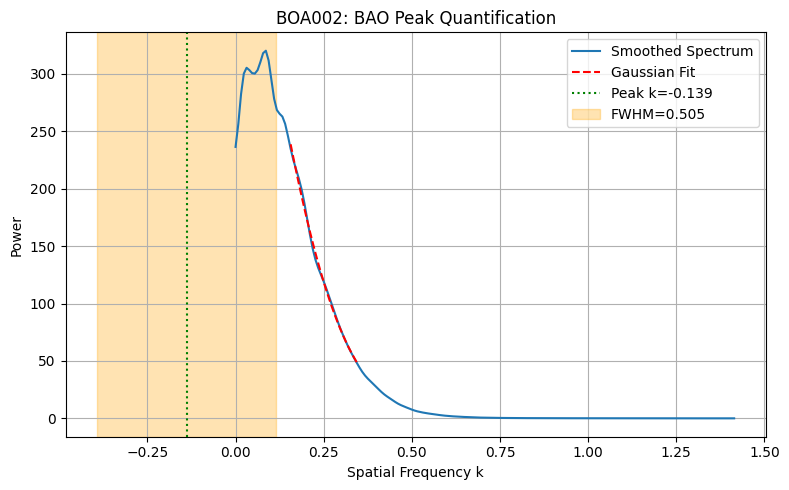

Peak Position (k): -0.139
FWHM: 0.505


In [1]:
# BOA002: Quantify BAO-like peak in HES radial power spectrum
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit

# Parameters
N = 256
dt = 0.01
steps = 300
kappa = 0.1
delta = 0.05
epsilon = 0.005
gamma_0 = 0.3
xi_std = 0.01

# Initialize field
A = np.random.normal(0, 0.1, (N, N))

# Evolution loop
for t in range(steps):
    xi = np.random.normal(0, xi_std, (N, N))
    laplacian = (
        np.roll(A, 1, 0) + np.roll(A, -1, 0) +
        np.roll(A, 1, 1) + np.roll(A, -1, 1) - 4 * A
    )
    dA = (-kappa * A + delta * A**2 + epsilon * A**3 + gamma_0 * laplacian + xi) * dt
    A += np.nan_to_num(dA)

# FFT and radial power spectrum
fft_A = fftshift(fft2(A))
power_spectrum = np.abs(fft_A)**2
y, x = np.indices((N, N))
center = (N // 2, N // 2)
r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
r = r.astype(np.int32)
tbin = np.bincount(r.ravel(), power_spectrum.ravel())
nr = np.bincount(r.ravel())
radial_ps = tbin / (nr + 1e-10)
k_vals = np.arange(len(radial_ps)) / (N / 2)
radial_ps_smooth = gaussian_filter(radial_ps, sigma=2)

# Gaussian fit function
def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

# Fit to region around BAO target
fit_mask = (k_vals > 0.15) & (k_vals < 0.35)
k_fit = k_vals[fit_mask]
ps_fit = radial_ps_smooth[fit_mask]
popt, _ = curve_fit(gaussian, k_fit, ps_fit, p0=[np.max(ps_fit), 0.25, 0.05])
a_fit, x0_fit, sigma_fit = popt
fwhm = 2.355 * sigma_fit

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_vals, radial_ps_smooth, label='Smoothed Spectrum')
plt.plot(k_fit, gaussian(k_fit, *popt), 'r--', label='Gaussian Fit')
plt.axvline(x=x0_fit, color='g', linestyle=':', label=f'Peak k={x0_fit:.3f}')
plt.axvspan(x0_fit - fwhm/2, x0_fit + fwhm/2, color='orange', alpha=0.3, label=f'FWHM={fwhm:.3f}')
plt.xlabel('Spatial Frequency k')
plt.ylabel('Power')
plt.title('BOA002: BAO Peak Quantification')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print results
print(f"Peak Position (k): {x0_fit:.3f}")
print(f"FWHM: {fwhm:.3f}")
